In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import pickle
import seaborn as sns
from matplotlib import gridspec
import plot_helper_functions as hf


In [32]:
# settings
non_feature_cols = ['SMILES', 'MP', 'MP_label', 'Type']
figure_output_dir = "../8_EDA"
data_types = ['L', 'H', 'All']
color_scheme = {
    'L': '#4c72b0', 
    'H': '#dd8452',
    'All': '#55a868', 
    'Purple': '#8172b3',
    'Red': "#e74c3c",
    'Extra': '#4d4d4d'}

In [33]:
all_data_path = '../0_data/processed_data/data_with_all_features_scaled.parquet'
L_data_path = '../0_data/processed_data/data_with_selected_features_LGB_L.parquet'
H_data_path = '../0_data/processed_data/data_with_selected_features_LGB_H.parquet'

In [36]:
H_cols = pd.read_parquet(H_data_path).columns.tolist()
L_cols = pd.read_parquet(L_data_path).columns.tolist()

# combine the two column lists and remove duplicates
combined_cols = list(dict.fromkeys(H_cols + L_cols))

print(f"H model features: {len(H_cols)}")
print(f"L model features: {len(L_cols)}")
print(f"Combined features: {len(combined_cols)}")

#figure_3_data_ = pd.read_parquet(figure_3_all_data_path)[combined_cols]
figure_data_ = pd.read_parquet(all_data_path)

figure_data = figure_data_[figure_data_['Type'] == 'Train']

print(f"Figure data shape: {figure_data.shape}")

H model features: 59
L model features: 93
Combined features: 100
Figure data shape: (12054, 388)


In [37]:
figure_data

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-1.155375,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,Train
1,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-0.552575,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,Train
2,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.482897,Cc1cc(Br)c(cc1Br)C,Train
3,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.495026,OC(=O)c1ccc(c(c1)F)C,Train
4,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.704817,OC(=O)C1CC(=O)c2c1cccc2,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12049,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,2.283989,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.737705,N#CCC(=O)c1ccc(c(c1)Cl)Cl,Train
12050,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,13.347631,-0.147667,-3.024733,CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC,Train
12051,0.0,0.0,0.0,-0.372678,1.605258,-0.476047,-0.437830,-0.433652,1.555810,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,0.755355,OC(=O)c1ccc2c(c1)CCCC2,Train
12052,0.0,0.0,0.0,-0.372678,-0.622953,-0.476047,-0.437830,-0.433652,-0.642752,-0.484941,...,-0.072601,-0.058421,-0.128257,-0.017216,-0.121843,-0.168229,-0.147667,-0.703209,COc1cccc(c1P(c1c(OC)cccc1OC)c1c(OC)cccc1OC)OC,Train


/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/G

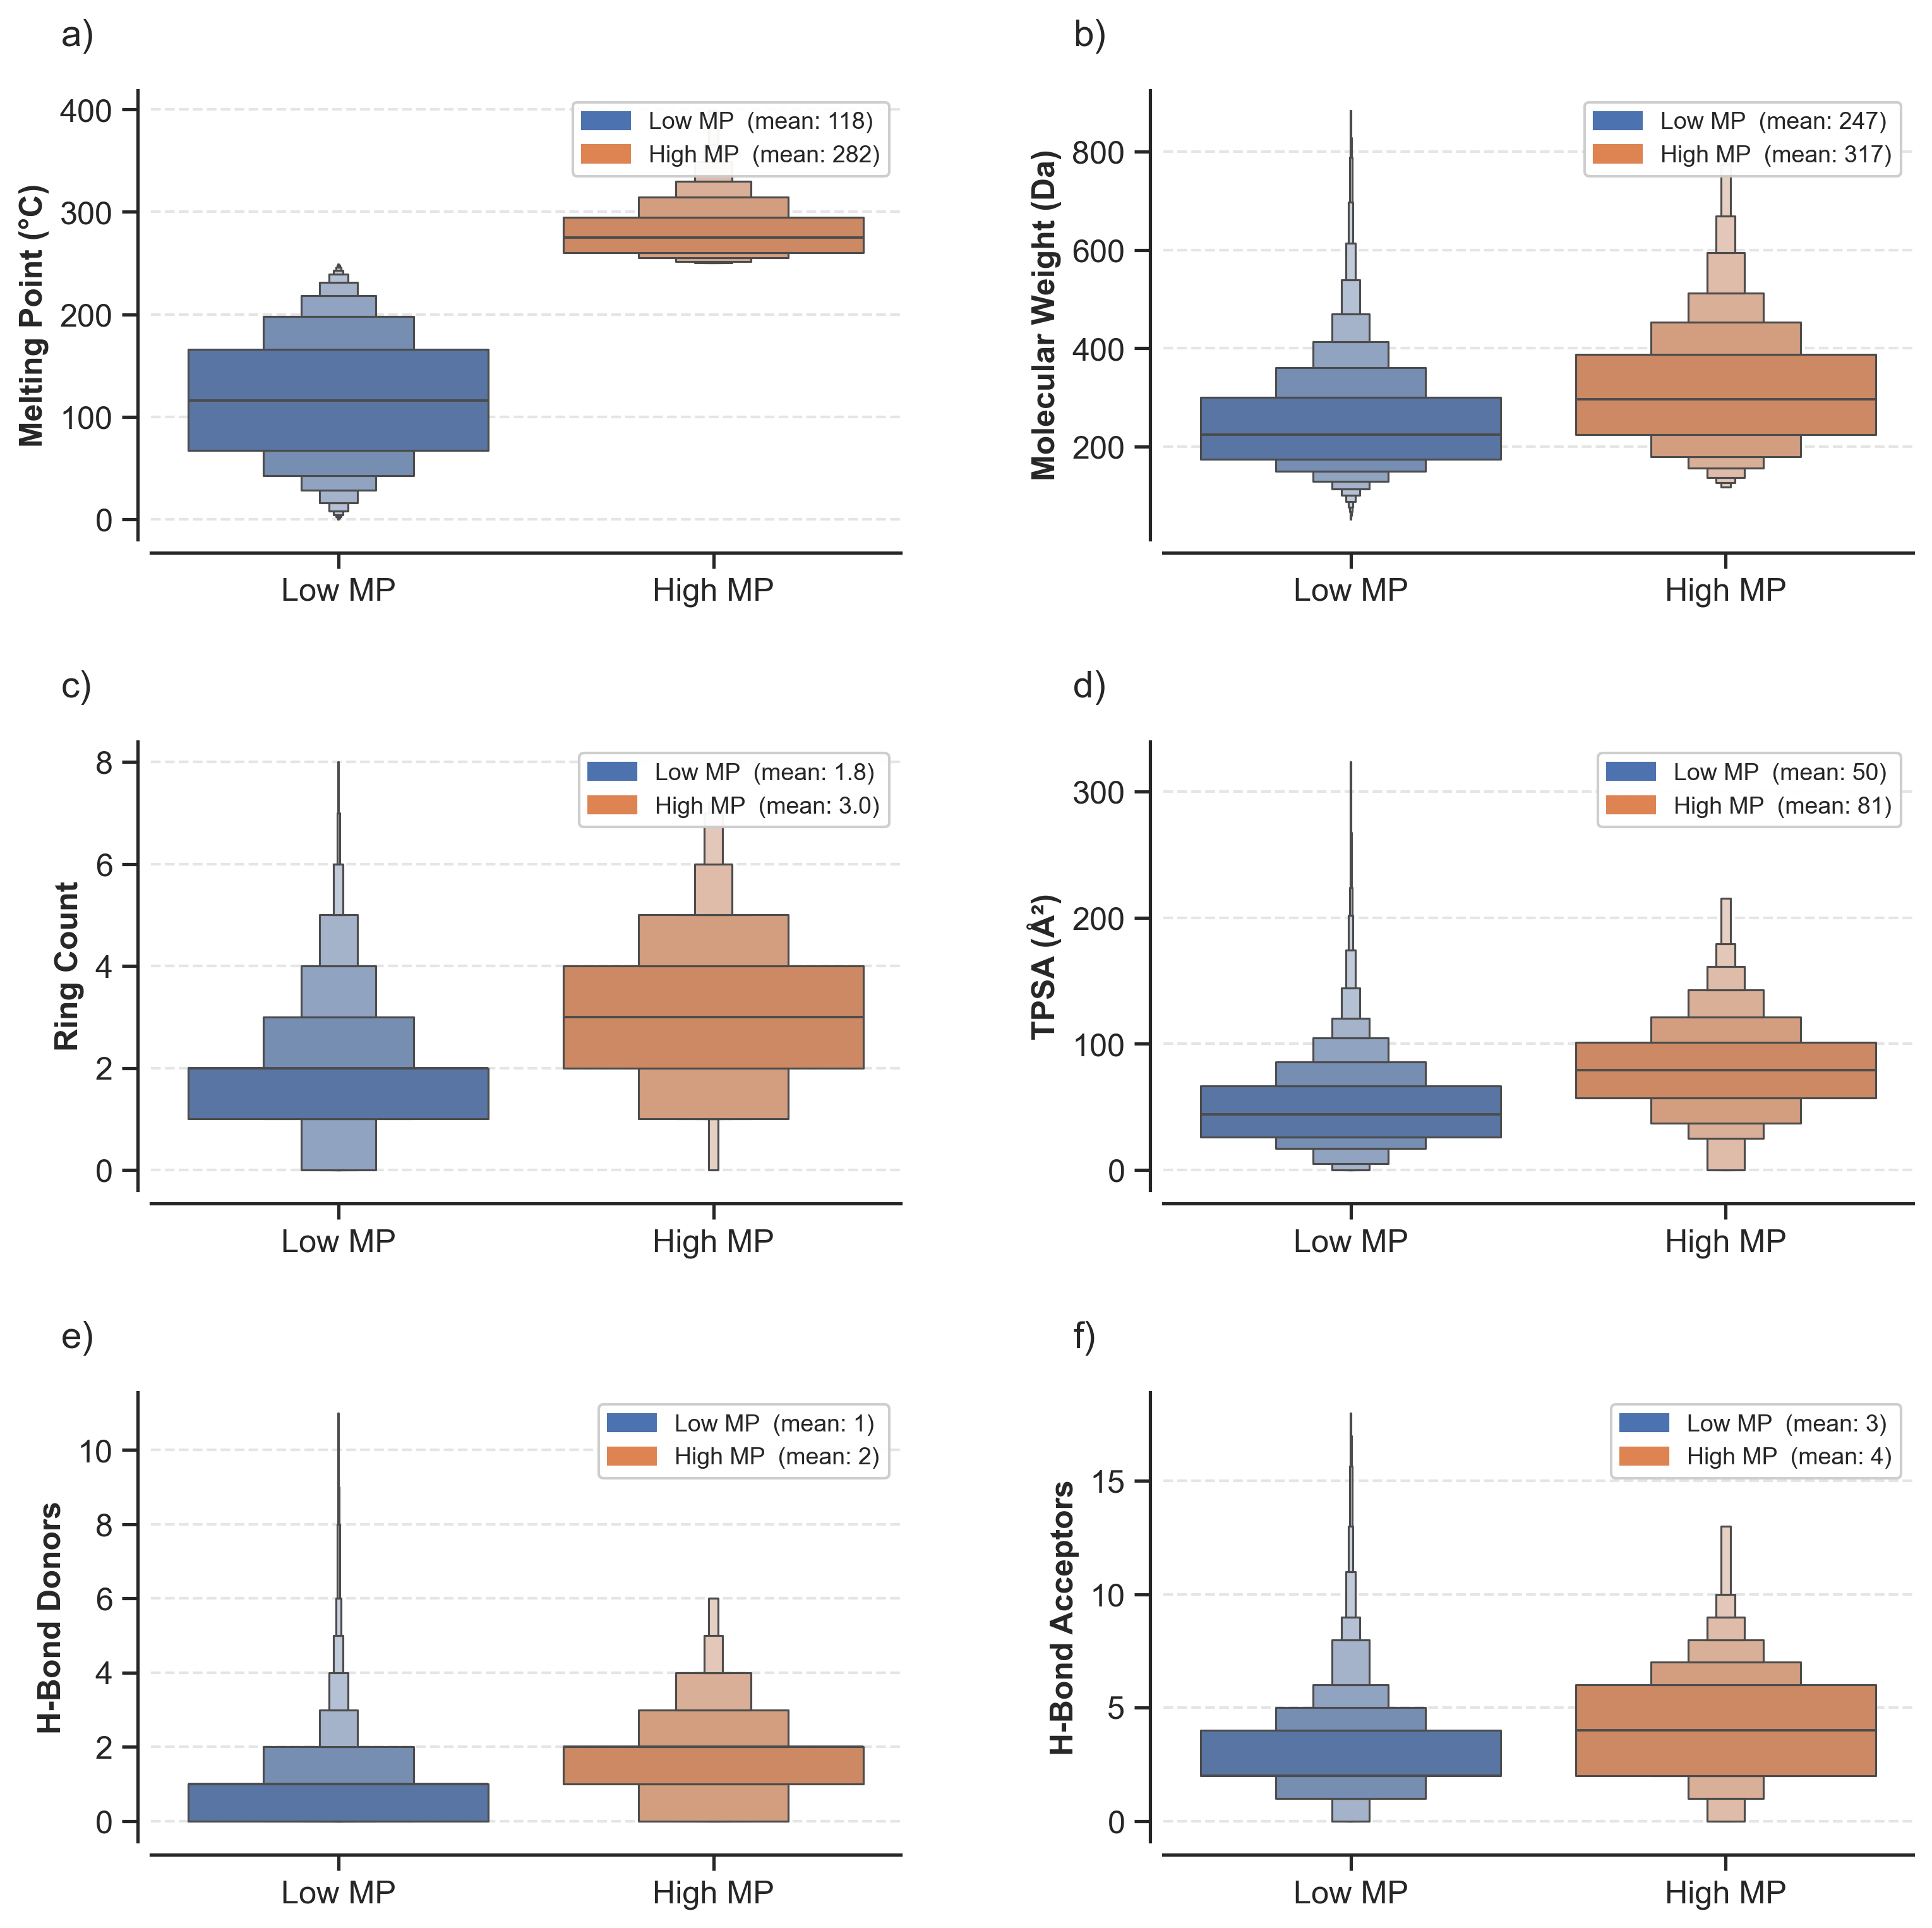

In [66]:
# 1. Added two more features (e.g., LogP and H-Bond Donors)
properties = [
    ('MP',        'Melting Point (°C)'),
    ('MW',        'Molecular Weight (Da)'),
    ('RingCount', 'Ring Count'),
    ('TPSA',      'TPSA (Å²)'),
    ('HBD',      'H-Bond Donors'),           # New Feature 1
    ('HBA',     'H-Bond Acceptors'),  # New Feature 2
]

sns.set_theme(style="ticks", font_scale=1.1)
fig = plt.figure(figsize=(12, 12)) # Adjusted height for the extra row

# 2. Redefined GridSpec to 3 rows and 2 columns for the 6 features
gs = gridspec.GridSpec(3, 2, figure=fig, wspace=0.35, hspace=0.45)

# 3. Simple list of all 6 positions in the 3x2 grid
prop_positions = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)]

for i, ((row, col), (prop, label)) in enumerate(zip(prop_positions, properties)):
    ax = fig.add_subplot(gs[row, col])
    
    # 4. Calling the original helper function with identical parameters
    hf.property_plot(figure_data, prop, label, ax=ax, x_col='MP_label',
                  color_scheme=color_scheme, smiles_col='SMILES', show_outliers=False,
                  ann=f'{chr(97+i)})', show_legend=True)

plt.tight_layout()
plt.show()

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/8_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/G

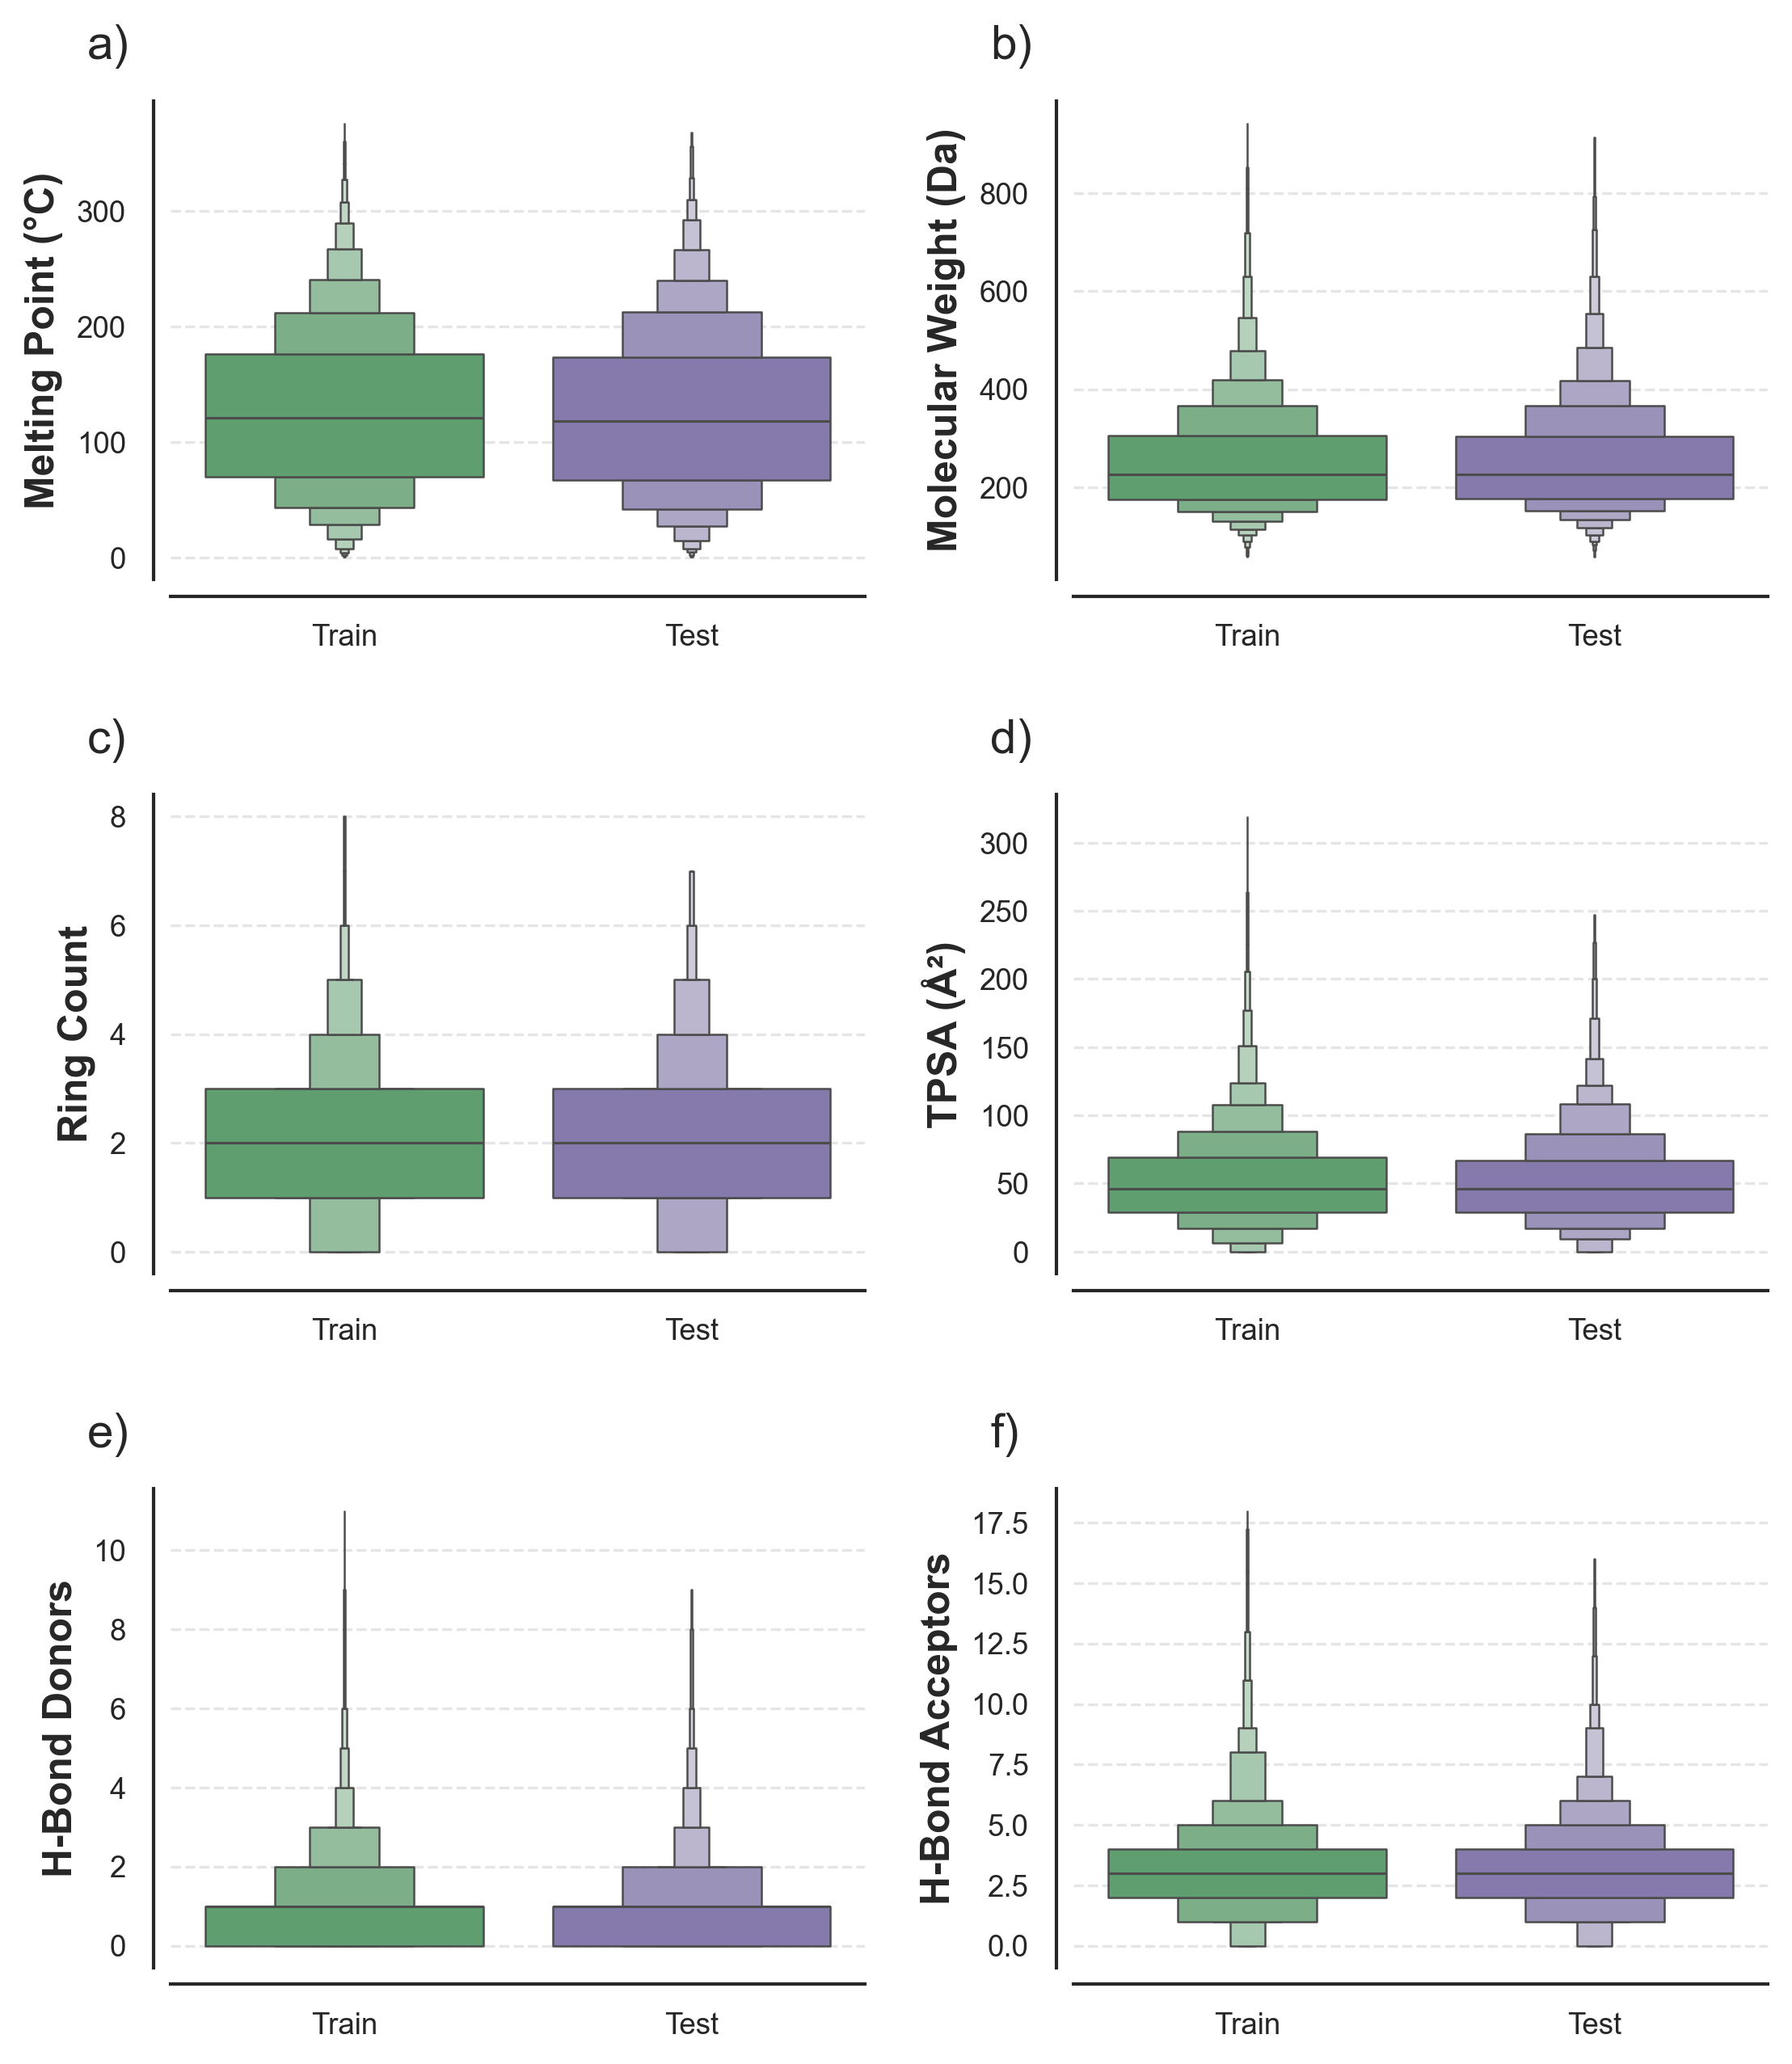

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# 1. Publication-style formatting (Same as main text)
sns.set_theme(style="white", context="paper")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 600,
})

# 2. Define Train/Test specific settings
# Create a new color scheme specifically for the data split
# Using the Green and Purple from your original palette dictionary
split_colors = {
    'Train': '#55a868', 
    'Test': '#8172b3'
}

# Ensure properties list is defined (just in case)
properties = [
    ('MP',        'Melting Point (°C)'),
    ('MW',        'Molecular Weight (Da)'),
    ('RingCount', 'Ring Count'),
    ('TPSA',      'TPSA (Å²)'),
    ('HBD',      'H-Bond Donors'),           
    ('HBA',       'H-Bond Acceptors'),  
]


# 3. Figure layout
# 3 rows, 2 columns layout 
fig = plt.figure(figsize=(8.5, 10)) # Slightly taller to fit 3 rows comfortably
gs = gridspec.GridSpec(3, 2, figure=fig, wspace=0.30, hspace=0.45)

prop_positions = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)]


# 4. Generate Plots
for i, ((row, col), (prop, label)) in enumerate(zip(prop_positions, properties)):
    ax = fig.add_subplot(gs[row, col])
    
    # Crucial Change: 
    # 1. Use figure_data_ (which contains BOTH Train and Test)
    # 2. Set x_col='Type' so the plotting function splits by Train/Test instead of L/H
    hf.property_plot(
        figure_data_, 
        prop, 
        label, 
        ax=ax, 
        x_col='Type',               # <--- The key modification
        color_scheme=split_colors,  # <--- New colors
        smiles_col='SMILES', 
        show_outliers=False,
        ann=f'{chr(97+i)})',        # Generates a), b), c), etc.
        show_legend=False           # Turn off legend to avoid clutter (Train/Test is on X-axis)
    )

    # Optional: Clean up spines for a more modern look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# plt.savefig(figure_output_dir + '/SI_train_test_distributions.png', dpi=600, bbox_inches='tight')

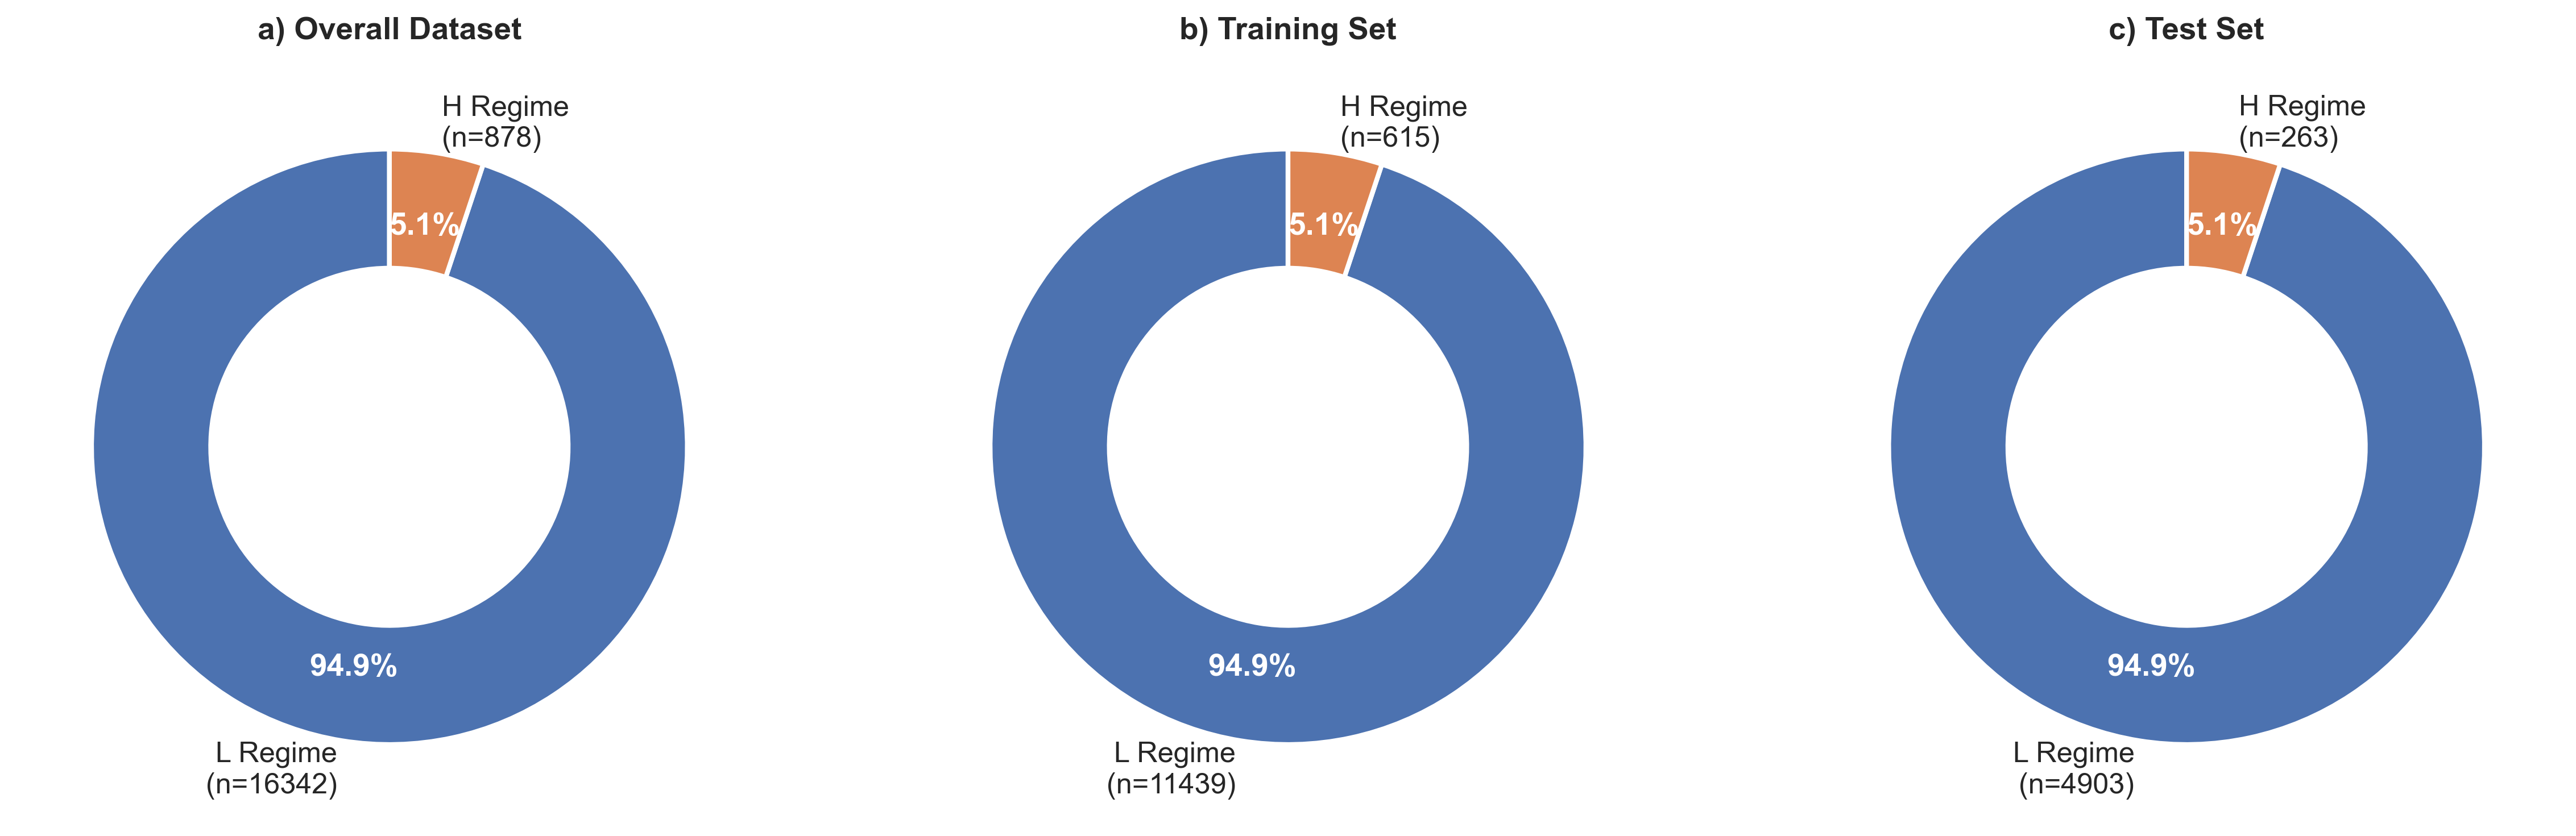

In [74]:
import matplotlib.pyplot as plt

# Filter data for Train and Test
train_data = figure_data_[figure_data_['Type'] == 'Train']
test_data  = figure_data_[figure_data_['Type'] == 'Test']  # Adjust 'Test' string if needed

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.set_theme(style="white", font_scale=1.1)

# Helper function to draw a single donut
def draw_donut(ax, df, title, ann):
    # Ensure consistent order L then H
    counts = df['MP_label'].value_counts().reindex(['L', 'H'])
    
    # Custom labels showing both the class and the raw count
    labels = [f"{idx} Regime\n(n={val})" for idx, val in zip(counts.index, counts.values)]
    colors = [color_scheme['L'], color_scheme['H']]
    
    # Plot the pie chart with a 'wedgeprop' to create the donut hole
    wedges, texts, autotexts = ax.pie(
        counts, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%', 
        startangle=90, 
        pctdistance=0.75,
        wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)
    )
    
    # Styling the text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        
    ax.set_title(f"{ann} {title}", pad=15, fontweight='bold')

# Draw the three panels
draw_donut(axes[0], figure_data_, 'Overall Dataset', 'a)')
draw_donut(axes[1], train_data, 'Training Set', 'b)')
draw_donut(axes[2], test_data, 'Test Set', 'c)')

plt.tight_layout()
plt.show()

# fig.savefig(figure_output_dir + '/dataset_imbalance_donuts.png', dpi=300)

/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_12121/2979734311.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


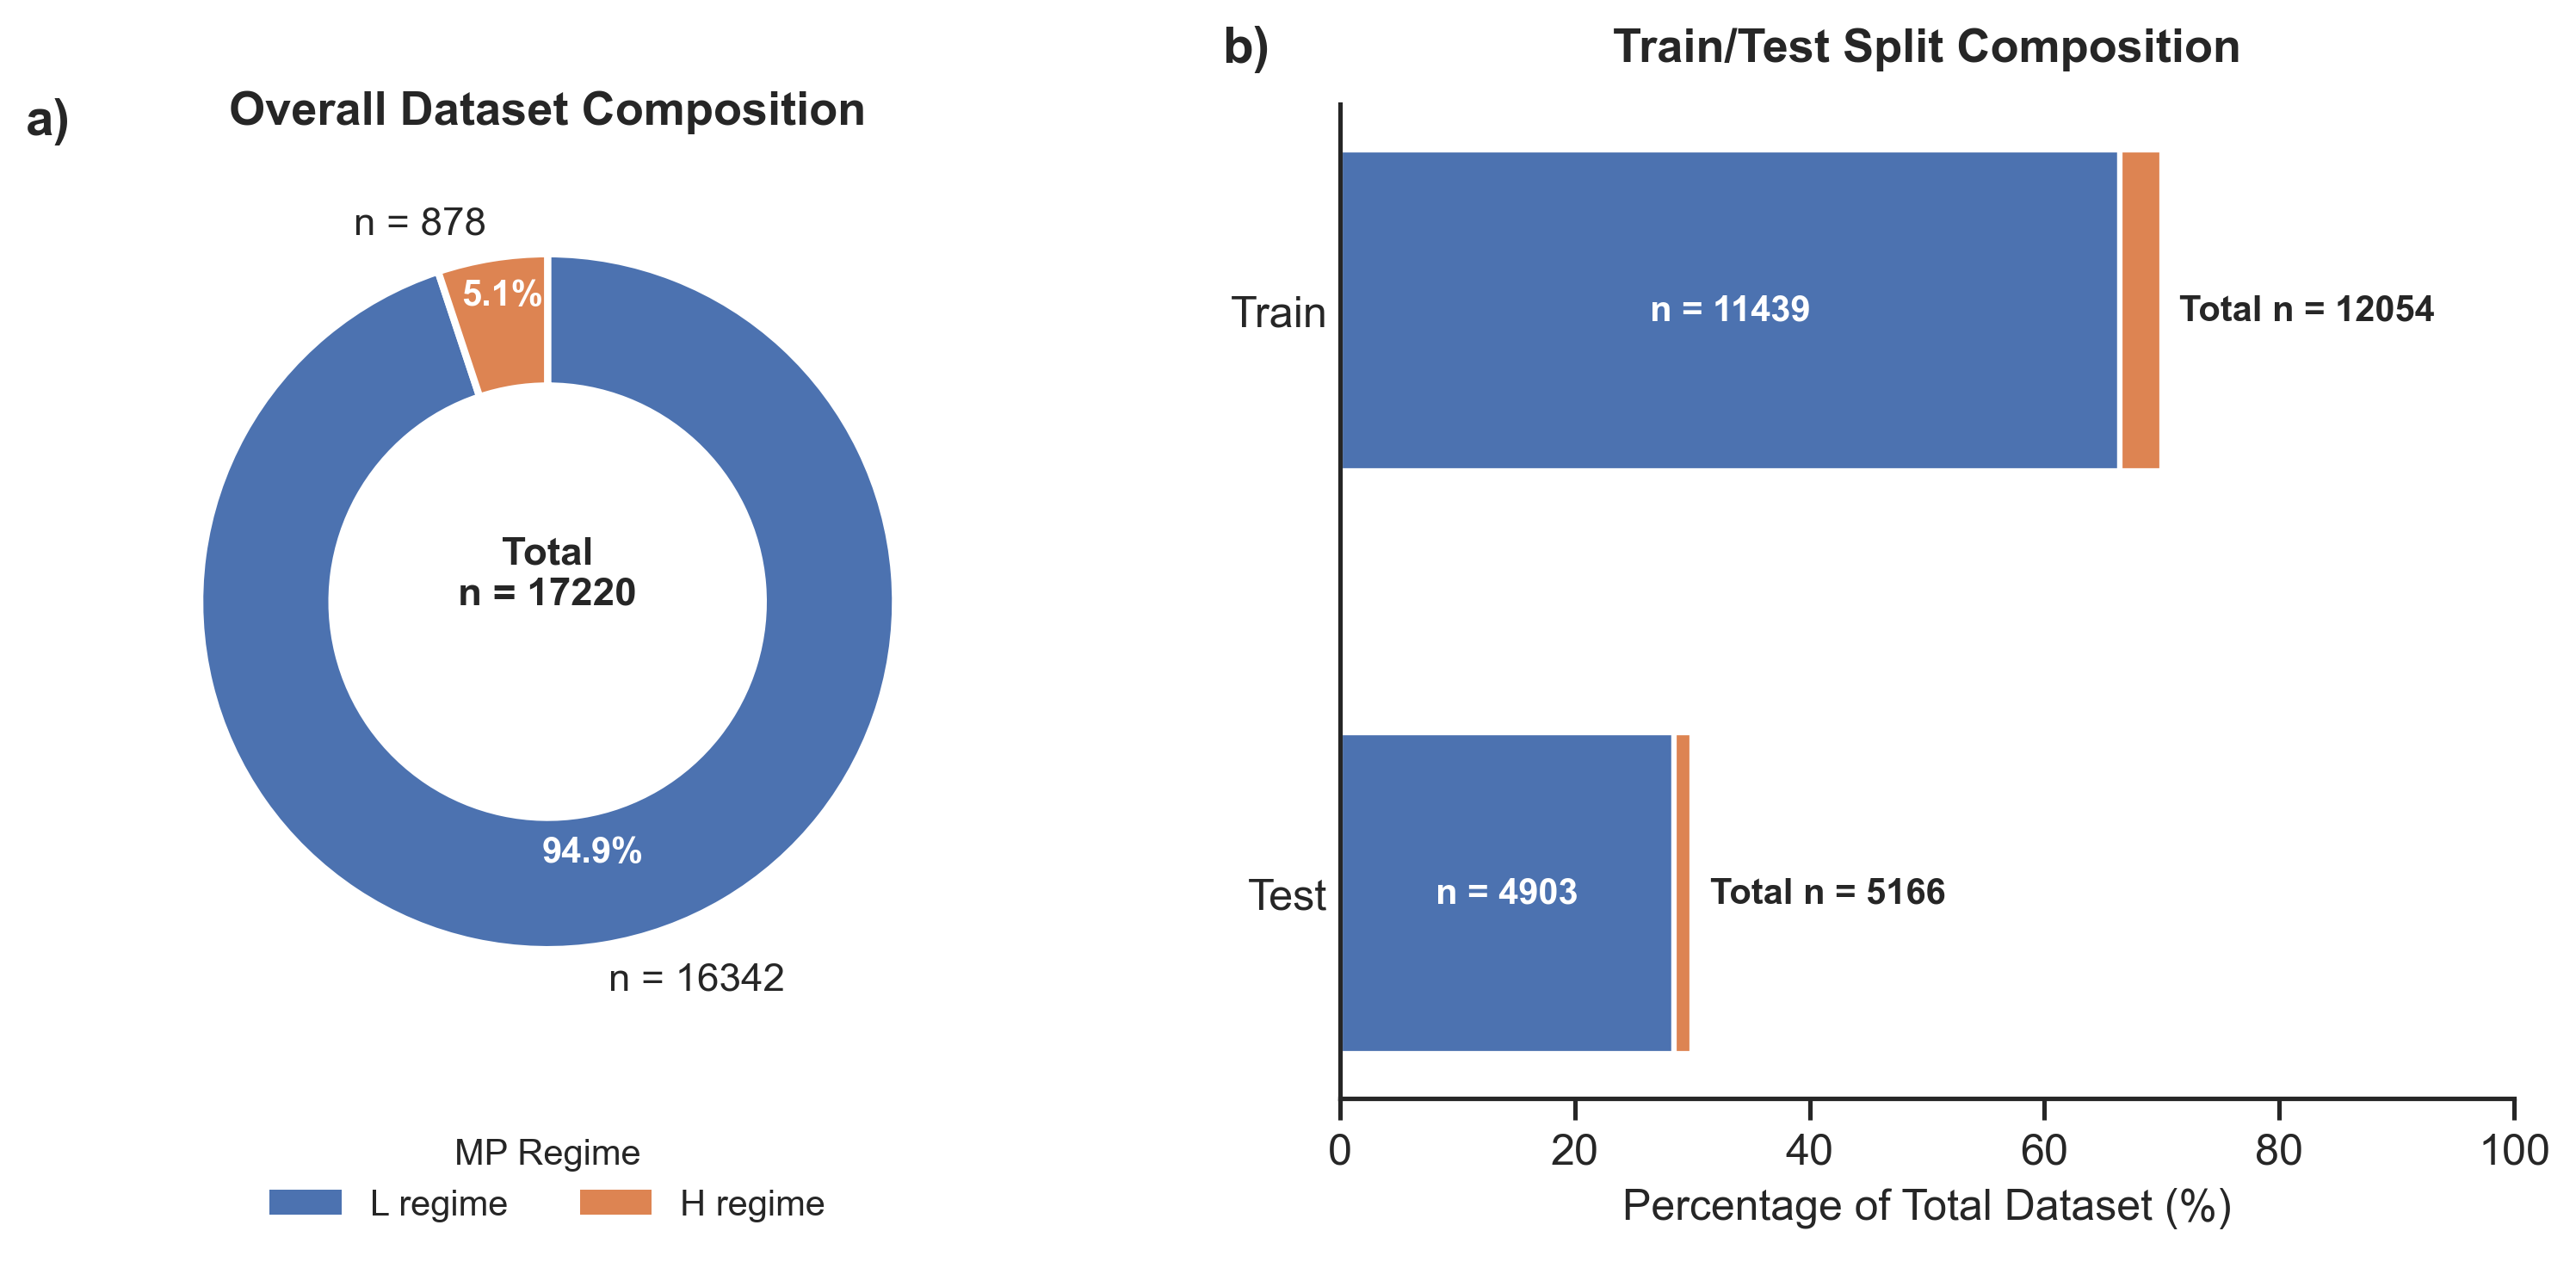

In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import seaborn as sns

# -----------------------------
# Match Figure 3 style
# -----------------------------
sns.set_theme(style="ticks", font_scale=1.1)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------
# Data preparation
# -----------------------------
N_total = len(figure_data_)

metrics = []

for t in ["Train", "Test"]:
    subset = figure_data_[figure_data_["Type"] == t]
    n_t = len(subset)

    counts = subset["MP_label"].value_counts().reindex(["L", "H"]).fillna(0)

    metrics.append({
        "Split Type": t,
        "Total Count": n_t,
        "Total Pct": (n_t / N_total) * 100,
        "L Count": int(counts["L"]),
        "L Pct": (counts["L"] / N_total) * 100,
        "H Count": int(counts["H"]),
        "H Pct": (counts["H"] / N_total) * 100
    })

df_metrics = pd.DataFrame(metrics)

# -----------------------------
# Figure layout
# -----------------------------
fig = plt.figure(figsize=(12, 5))

gs = gridspec.GridSpec(
    1, 2,
    figure=fig,
    width_ratios=[1.0, 1.35],
    wspace=0.35
)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# -----------------------------
# Panel a): Donut chart
# -----------------------------
counts = figure_data_["MP_label"].value_counts().reindex(["L", "H"]).fillna(0)

labels = [
    f"n = {int(count)}"
    for count in counts.values
]

colors = [color_scheme["L"], color_scheme["H"]]

wedges, texts, autotexts = ax0.pie(
    counts,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct="%1.1f%%",
    pctdistance=0.72,
    labeldistance=1.10,
    wedgeprops=dict(width=0.38, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11),
    center=(0, -0.08)   # 👈 THIS LINE (shift down slightly)
)

# --- Fix percentage label alignment ---
inner_radius = 1 - 0.38  # matches your wedge width
r = inner_radius + (0.38 / 2)  # midpoint of the ring

for wedge, autotext in zip(wedges, autotexts):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = r * np.cos(np.deg2rad(angle))
    y = r * np.sin(np.deg2rad(angle))
    
    autotext.set_position((x, y))
    autotext.set_ha('center')
    autotext.set_va('center')

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")

ax0.text(
    0, 0,
    f"Total\nn = {N_total}",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)

ax0.set_title("Overall Dataset Composition", fontsize=13, fontweight="bold", pad=12)

ax0.text(
    -0.10, 1.08, "a)",
    transform=ax0.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

# Legend under left panel
legend_handles = [
    Patch(facecolor=color_scheme["L"], edgecolor="none", label="L regime"),
    Patch(facecolor=color_scheme["H"], edgecolor="none", label="H regime")
]

ax0.legend(
    handles=legend_handles,
    title="MP Regime",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False,
    fontsize=10,
    title_fontsize=10
)

# -----------------------------
# Panel b): Horizontal stacked bar
# -----------------------------
y = np.arange(len(df_metrics))
bar_height = 0.55

ax1.barh(
    y,
    df_metrics["L Pct"],
    height=bar_height,
    color=color_scheme["L"],
    edgecolor="white",
    linewidth=1.5,
    label="L regime"
)

ax1.barh(
    y,
    df_metrics["H Pct"],
    height=bar_height,
    left=df_metrics["L Pct"],
    color=color_scheme["H"],
    edgecolor="white",
    linewidth=1.5,
    label="H regime"
)

for i, row in df_metrics.iterrows():
    l_pct = row["L Pct"]
    h_pct = row["H Pct"]
    total_pct = row["Total Pct"]

    if l_pct > 4:
        ax1.text(
            l_pct / 2,
            i,
            f"n = {row['L Count']}",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    if h_pct > 4:
        ax1.text(
            l_pct + h_pct / 2,
            i,
            f"n = {row['H Count']}",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

    ax1.text(
        total_pct + 1.5,
        i,
        f"Total n = {row['Total Count']}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

ax1.set_yticks(y)
ax1.set_yticklabels(df_metrics["Split Type"])
ax1.invert_yaxis()

ax1.set_xlim(0, 100)
ax1.set_xlabel("Percentage of Total Dataset (%)", fontsize=12)
ax1.set_title("Train/Test Split Composition", fontsize=13, fontweight="bold", pad=12)

ax1.text(
    -0.10, 1.08, "b)",
    transform=ax1.transAxes,
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)

# Match seaborn ticks style
sns.despine(ax=ax1, top=True, right=True, left=False, bottom=False)
ax1.tick_params(axis="y", length=0)
ax1.grid(False)

plt.tight_layout()

# Optional export
# fig.savefig(figure_output_dir + "figure_dataset_composition.png", dpi=300, bbox_inches="tight")
# fig.savefig(figure_output_dir + "figure_dataset_composition.pdf", bbox_inches="tight")

plt.show()